# Entrenamiento: Predicción de IS_FRAUD (binaria)

Este notebook entrena y evalúa múltiples modelos para predecir **fraude**.
Incluye CatBoost y feature engineering avanzado anti-leakage.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, make_scorer, fbeta_score)
import xgboost as xgb
import lightgbm as lgb
try:
    import catboost as cb
    CATBOOST_AVAIL = True
except ImportError:
    CATBOOST_AVAIL = False
    print('CatBoost no instalado — se omite')
sys.path.append(str(Path.cwd().parent))
from model.feature_engineering import *
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('OK')

OK


## 1. Carga de datos

In [2]:
DATA_PATH = Path.cwd().parent / 'Notebooks' / 'data' / 'dataset_fraude.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nDistribución de IS_FRAUD:')
print(df['IS_FRAUD'].value_counts())
print(f'\nFraude: {df["IS_FRAUD"].mean()*100:.2f}%')
df.head(3)

Shape: (10000, 45)

Distribución de IS_FRAUD:
IS_FRAUD
0    8474
1    1526
Name: count, dtype: int64

Fraude: 15.26%


,id_cliente,tipo_cliente,edad_cliente,customer_country,customer_region,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,...,identificador_dispositivo_fingerprint,dispositivo_reconocido,operacion_pais,operacion_region,direccion_ip_origen,geolocalizacion,cuenta_destino,destino_alto_riesgo,IS_FRAUD,IMPACTO_FRAUDE
0,3ddebd45-ccd,empresa,57,ES,Centro,3364,21.97,292.59,1.58,0,...,fa1bdf50-1c95-45,1,ES,Centro,86.34.12.179,"40.4168,-3.7038",ES169540317577,0,0,0
1,12625769-3f8,persona,68,FR,Normandía,2068,283.70,1425.40,2.99,0,...,1d0337cd-8f7a-42,1,FR,Bretaña,90.14.61.52,"48.8566,2.3522",ES735546725072,1,0,0
2,b5768bae-00f,persona,62,PT,Oporto,1671,83.21,537.38,11.62,0,...,0bf03526-6f4e-42,1,PT,Oporto,85.128.118.137,"41.1579,-8.6291",ES833936678283,0,0,0


In [3]:
# Eliminar el otro target para evitar data leakage
df.drop(columns=['IMPACTO_FRAUDE'], inplace=True)
print('IMPACTO_FRAUDE eliminado — shape:', df.shape)

IMPACTO_FRAUDE eliminado — shape: (10000, 44)


## 2. Train/Test split (ANTES del FE)

In [4]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['IS_FRAUD']
)
print(f'Train: {train_df.shape[0]}  Test: {test_df.shape[0]}')
print(f'Train rate: {train_df["IS_FRAUD"].mean()*100:.2f}%')
print(f'Test rate:  {test_df["IS_FRAUD"].mean()*100:.2f}%')

Train: 8000  Test: 2000
Train rate: 15.26%
Test rate:  15.25%


## 3. Feature Engineering

In [5]:
fe = FeatureEngineer(encode_target='IS_FRAUD', random_state=42)
X_train = fe.fit_transform(train_df)
y_train = X_train.pop('IS_FRAUD').values
X_test = fe.transform(test_df)
y_test = X_test.pop('IS_FRAUD').values
num_feats = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f'Features: {X_train.shape[1]}  Train rows: {X_train.shape[0]}')
X_train.head(3)

Features: 62  Train rows: 8000


,edad_cliente,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,numero_transferencias_recibidas_7_dias,...,estado_tarjeta_freq,estado_tarjeta_target,tipo_transaccion_freq,tipo_transaccion_target,metodo_autenticacion_freq,metodo_autenticacion_target,operacion_pais_freq,operacion_pais_target,operacion_region_freq,operacion_region_target
394,83,3493,2014.45,457.79,1.09,2119.10,2529.38,1115.42,2114.47,3,...,6384,0.123434,2369,0.193753,1156,0.176471,1255,0.156972,358,0.150838
3807,32,190,245.77,173.74,1.43,221.29,182.90,864.86,10981.79,2,...,681,0.111601,2369,0.193753,1156,0.176471,486,0.187243,170,0.211765
1412,22,1219,1490.31,922.65,1.15,1337.22,1207.33,45.86,2615.67,2,...,6384,0.123434,5631,0.135322,1156,0.176471,649,0.167951,159,0.132075


In [6]:
scaler = StandardScaler()
Xtr = X_train.copy(); Xte = X_test.copy()
Xtr[num_feats] = scaler.fit_transform(X_train[num_feats])
Xte[num_feats] = scaler.transform(X_test[num_feats])
print('Scaled')

Scaled


## 4. Modelos con GridSearchCV

**Modelos:** LogisticRegression, RandomForest, GradientBoosting, XGBoost, LightGBM, ExtraTrees, KNN, SVM, CatBoost

In [7]:
models = [
    ('LogisticRegression', LogisticRegression(), {'C': [0.01, 0.1, 1, 10], 'max_iter': [1000], 'class_weight': [None, 'balanced']}),
    ('RandomForest', RandomForestClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'class_weight': [None, 'balanced']}),
    ('GradientBoosting', GradientBoostingClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}),
    ('XGBoost', xgb.XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'), {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1], 'scale_pos_weight': [1, 3, 5]}),
    ('LightGBM', lgb.LGBMClassifier(random_state=42, verbose=-1), {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 63], 'class_weight': [None, 'balanced']}),
    ('ExtraTrees', ExtraTreesClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'class_weight': [None, 'balanced']}),
    ('KNN', KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}),
    ('SVM', SVC(probability=True, random_state=42), {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}),
]
if CATBOOST_AVAIL:
    models.append(('CatBoost', cb.CatBoostClassifier(random_state=42, verbose=False, eval_metric='AUC'),
                   {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]}))

f2 = make_scorer(fbeta_score, beta=2, pos_label=1)
results = []; bests = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, est, params in models:
    print(f'\n>>> {name}')
    gs = GridSearchCV(est, params, cv=cv, scoring=f2, n_jobs=-1)
    gs.fit(Xtr, y_train)
    bests[name] = gs.best_estimator_
    yprob = gs.predict_proba(Xte)[:, 1]
    results.append({'modelo': name, 'cv_auprc': gs.best_score_,
                    'test_auc': roc_auc_score(y_test, yprob),
                    'test_auprc': average_precision_score(y_test, yprob)})
    print(f'  CV AUPRC={gs.best_score_:.4f}  AUC={results[-1]["test_auc"]:.4f}  AUPRC={results[-1]["test_auprc"]:.4f}')

res = pd.DataFrame(results).sort_values('test_auprc', ascending=False)
print('\n' + '='*60)
print('RESUMEN (ordenado por AUPRC)')
print('='*60)
print(res[['modelo','cv_auprc','test_auc','test_auprc']].round(4).to_string(index=False))


>>> LogisticRegression
  CV AUPRC=0.5364  AUC=0.7620  AUPRC=0.3727

>>> RandomForest
  CV AUPRC=0.4915  AUC=0.7565  AUPRC=0.3458

>>> GradientBoosting
  CV AUPRC=0.1629  AUC=0.7472  AUPRC=0.3506

>>> XGBoost
  CV AUPRC=0.5177  AUC=0.7704  AUPRC=0.3655

>>> LightGBM
  CV AUPRC=0.5348  AUC=0.7656  AUPRC=0.3629

>>> ExtraTrees
  CV AUPRC=0.5242  AUC=0.7499  AUPRC=0.3436

>>> KNN
  CV AUPRC=0.1442  AUC=0.5916  AUPRC=0.2026

>>> SVM
  CV AUPRC=0.2194  AUC=0.6778  AUPRC=0.2873

>>> CatBoost
  CV AUPRC=0.1358  AUC=0.7569  AUPRC=0.3644

RESUMEN (ordenado por AUPRC)
            modelo  cv_auprc  test_auc  test_auprc
LogisticRegression    0.5364    0.7620      0.3727
           XGBoost    0.5177    0.7704      0.3655
          CatBoost    0.1358    0.7569      0.3644
          LightGBM    0.5348    0.7656      0.3629
  GradientBoosting    0.1629    0.7472      0.3506
      RandomForest    0.4915    0.7565      0.3458
        ExtraTrees    0.5242    0.7499      0.3436
               SVM    0.219

## 5. Mejor modelo

In [8]:
best_name = res.iloc[0]['modelo']
best = bests[best_name]
print(f'Mejor modelo (mayor F2): {best_name}')

# 1. Out-of-fold raw probabilities for robust threshold
cv5 = StratifiedKFold(5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(best, Xtr, y_train, cv=cv5, method='predict_proba', n_jobs=-1)[:, 1]

# 2. Threshold on raw OOF probs (recall-first: max precision subject to recall >= 90%)
target_recall = 0.90
thrs = np.linspace(0.01, 0.9, 400)
best_t = None; best_p = -1; best_r = 0
for t in thrs:
    yt = (oof_probs >= t).astype(int)
    r = recall_score(y_train, yt)
    p = precision_score(y_train, yt)
    if r >= target_recall and p > best_p:
        best_t, best_p, best_r = t, p, r
print(f'Threshold OOF raw: {best_t:.4f}  Recall={best_r:.4f}  Precision={best_p:.4f}')

# 3. Apply same threshold to test (raw probabilities from best.model)
yprob = best.predict_proba(Xte)[:, 1]
yp_opt = (yprob >= best_t).astype(int)

# 4. Final metrics
print()
print(classification_report(y_test, yp_opt, digits=4))
alerts = yp_opt.sum()
alerts_per_100k = alerts / len(Xte) * 100000
print(f'Alertas totales: {alerts}  Alertas/100k: {alerts_per_100k:.1f}')


Mejor modelo (mayor F2): LogisticRegression
Threshold OOF raw: 0.3089  Recall=0.9017  Precision=0.2170

              precision    recall  f1-score   support

           0     0.9694    0.4301    0.5958      1695
           1     0.2260    0.9246    0.3632       305

    accuracy                         0.5055      2000
   macro avg     0.5977    0.6773    0.4795      2000
weighted avg     0.8560    0.5055    0.5604      2000

Alertas totales: 1248  Alertas/100k: 62400.0


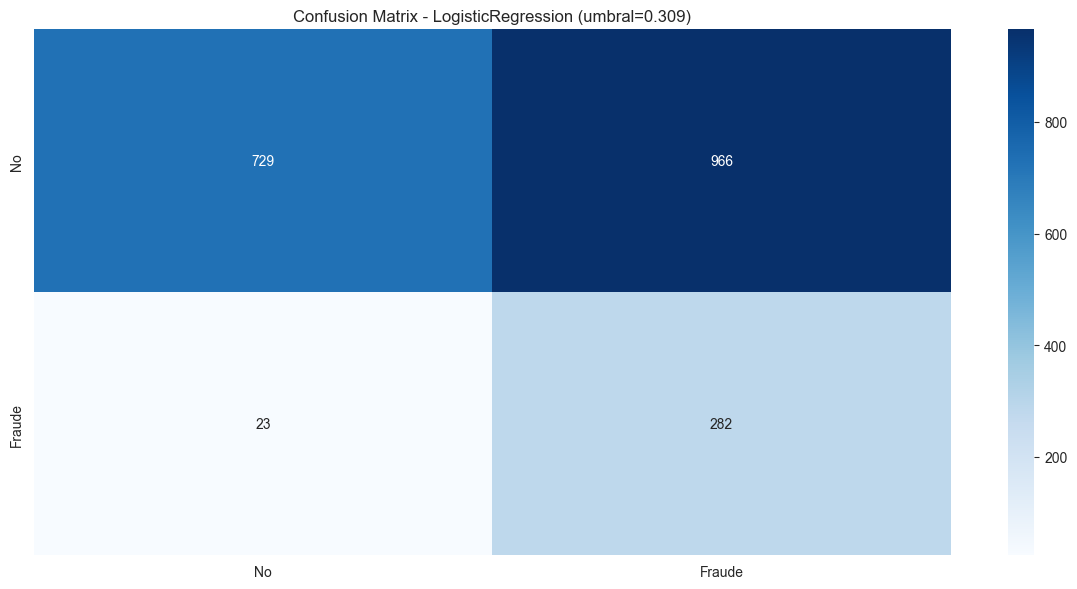

In [9]:
cm = confusion_matrix(y_test, yp_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Fraude'], yticklabels=['No','Fraude'])
plt.title(f'Confusion Matrix - {best_name} (umbral={best_t:.3f})'); plt.tight_layout(); plt.show()

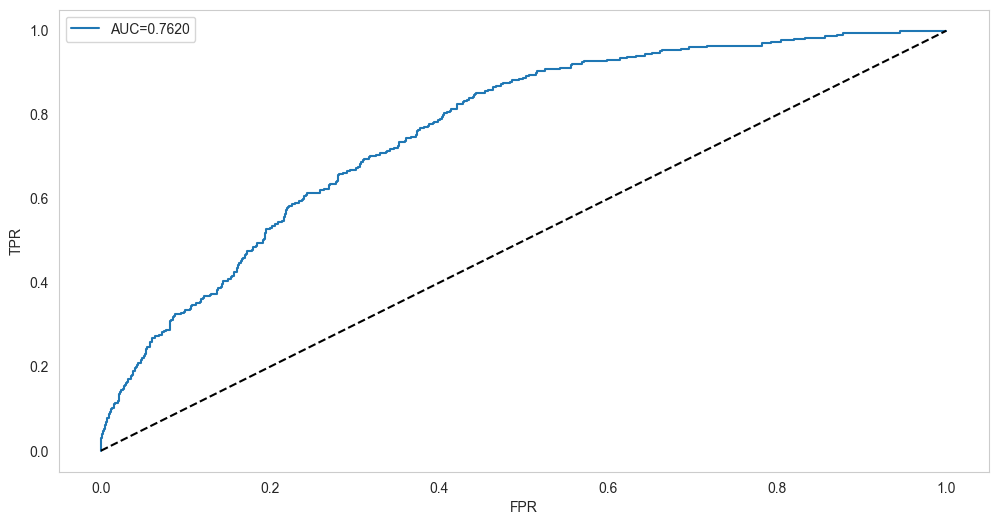

In [10]:
fpr, tpr, _ = roc_curve(y_test, yprob)
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, yprob):.4f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.grid(); plt.show()

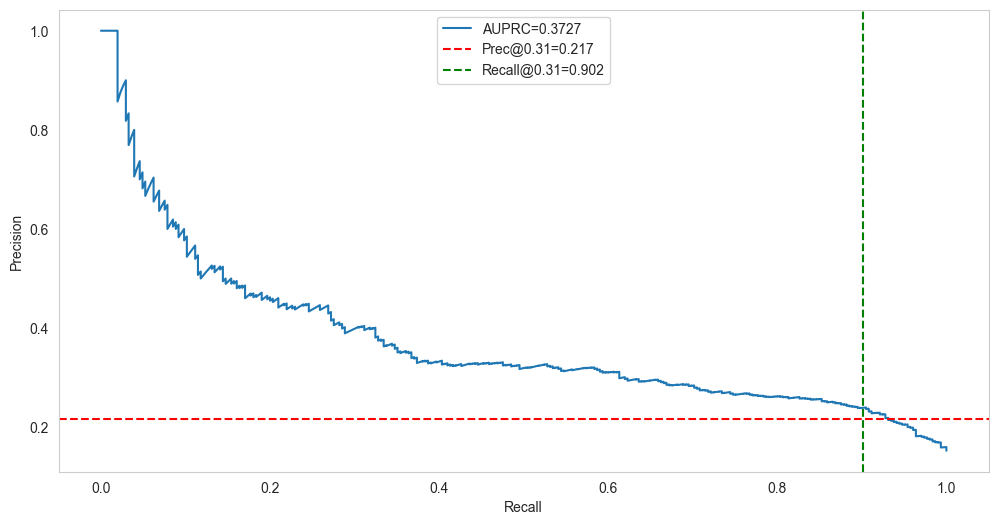

In [11]:
prec, rec, _ = precision_recall_curve(y_test, yprob)
plt.plot(rec, prec, label=f'AUPRC={average_precision_score(y_test, yprob):.4f}')
plt.axhline(best_p, color='r', ls='--', label=f'Prec@{best_t:.2f}={best_p:.3f}')
plt.axvline(best_r, color='g', ls='--', label=f'Recall@{best_t:.2f}={best_r:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(); plt.grid(); plt.show()

## 6. Importancia

In [12]:
if hasattr(best, 'feature_importances_'):
    imp = pd.DataFrame({'f': Xtr.columns, 'imp': best.feature_importances_}).sort_values('imp', ascending=False)
    sns.barplot(data=imp.head(20), x='imp', y='f', palette='viridis')
    plt.title(f'Top-20 - {best_name}'); plt.tight_layout(); plt.show()
    print(imp.head(10).to_string(index=False))

## 7. Threshold sweep (Recall-first)

Se elige el threshold que maximiza precisión sujeto a recall ≥ 90%.

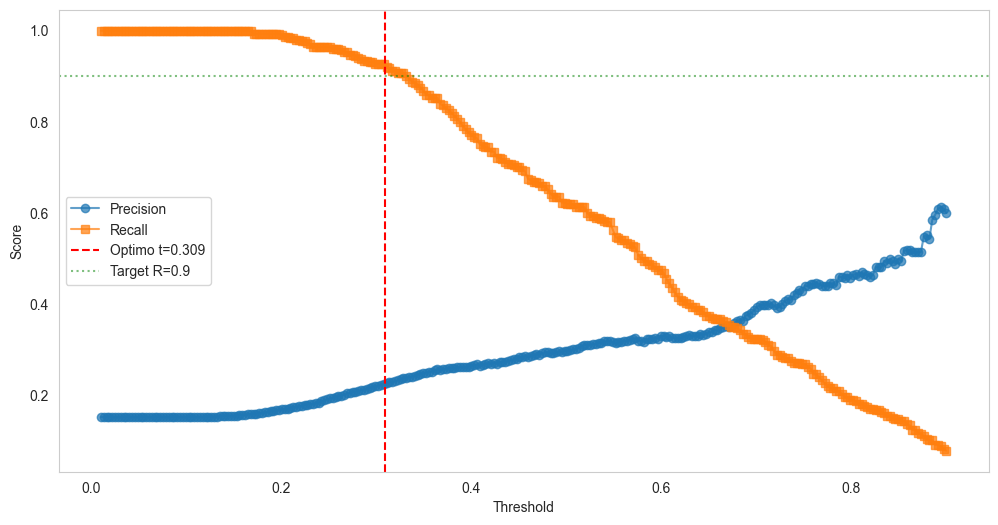

Threshold=0.309  Recall=0.902  Precision=0.217


In [13]:
thrs = np.linspace(0.01, 0.9, 300)
sc = []
for t in thrs:
    yt = (yprob >= t).astype(int)
    sc.append({'t': t, 'p': precision_score(y_test, yt), 'r': recall_score(y_test, yt)})
sc = pd.DataFrame(sc)
plt.plot(sc['t'], sc['p'], 'o-', label='Precision', alpha=0.7)
plt.plot(sc['t'], sc['r'], 's-', label='Recall', alpha=0.7)
plt.axvline(best_t, color='r', ls='--', label=f'Optimo t={best_t:.3f}')
plt.axhline(target_recall, color='g', ls=':', alpha=0.5, label=f'Target R={target_recall}')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.legend(); plt.grid(); plt.show()
print(f'Threshold={best_t:.3f}  Recall={best_r:.3f}  Precision={best_p:.3f}')

## 8. Conclusiones

In [14]:
print('=== FINAL ===')
print(f'Mejor modelo: {best_name}')
print(f'Threshold optimizado: {best_t:.3f}')
print(f'  Recall (fraude):  {best_r:.3f}  (captura {best_r*100:.1f}% de los fraudes)')
print(f'  Precision (fraude): {best_p:.3f}')
print(f'Test AUPRC (calibrado): {average_precision_score(y_test, yprob):.4f}')
print(f'Test AUC:   {roc_auc_score(y_test, yprob):.4f}')
alerts_100k = yp_opt.sum() / len(Xte) * 100000
print(f'Threshold OOF: {best_t:.4f}  Alertas/100k: {alerts_100k:.1f}')
print(f'\nDataset: {len(df)} txns, {df["IS_FRAUD"].mean()*100:.2f}% fraude')


=== FINAL ===
Mejor modelo: LogisticRegression
Threshold optimizado: 0.309
  Recall (fraude):  0.902  (captura 90.2% de los fraudes)
  Precision (fraude): 0.217
Test AUPRC (calibrado): 0.3727
Test AUC:   0.7620
Threshold OOF: 0.3089  Alertas/100k: 62400.0

Dataset: 10000 txns, 15.26% fraude
